# 04 · RFM segmentation

Recency / Frequency / Monetary customer segmentation with KMeans,
validated with silhouette score across k=2–8 rather than picked by eye.
Built on `customer_unique_id` (see notebook 03, section 4).

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

In [2]:
orders = pd.read_parquet(PROCESSED / "orders_clean.parquet")

# RFM base: delivered orders only, consistent with every other
# "completed sale" metric in this project.
base = orders[orders["order_status"] == "delivered"].copy()
base["order_purchase_timestamp"] = pd.to_datetime(base["order_purchase_timestamp"])
snapshot_date = base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = base.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda s: (snapshot_date - s.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("order_total_value", "sum"),
).reset_index()

print(f"Snapshot date: {snapshot_date.date()}  |  Customers: {len(rfm):,}")
rfm[["recency_days", "frequency", "monetary"]].describe()

Snapshot date: 2018-08-30  |  Customers: 93,358


,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.168210
std,152.591453,0.209097,226.292101
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.010000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.510000
max,714.000000,15.000000,13664.080000


In [3]:
# Log-transform frequency & monetary: both are heavily right-skewed (most
# customers buy once), which would let a few high-spend outliers dominate
# Euclidean distance in KMeans.
rfm["frequency_log"] = np.log1p(rfm["frequency"])
rfm["monetary_log"] = np.log1p(rfm["monetary"])

X = rfm[["recency_days", "frequency_log", "monetary_log"]].copy()
X_scaled = StandardScaler().fit_transform(X)

## Choose k with silhouette score
Silhouette is computed on a fixed 10,000-row sample per k (full pairwise
silhouette on ~96k rows is O(n²) and impractical).

In [4]:
sil_scores, inertias = {}, {}
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_scaled), size=min(10000, len(X_scaled)), replace=False
)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias[k] = km.inertia_
    sil_scores[k] = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[k]:.4f}")

statistically_best_k = max(sil_scores, key=sil_scores.get)

k=2  inertia=190,196  silhouette=0.7069


k=3  inertia=126,273  silhouette=0.3597


k=4  inertia=85,766  silhouette=0.3708


k=5  inertia=70,368  silhouette=0.3563


k=6  inertia=59,309  silhouette=0.3452


k=7  inertia=50,724  silhouette=0.3572


k=8  inertia=45,145  silhouette=0.3437


k=2 wins on silhouette, but that's a near-trivial "bought once vs. more
than once" split (~97% of customers have frequency==1) — geometrically
clean, not a useful business segmentation. Decision: report k=2 as the
statistically optimal answer, and separately use the best *actionable*
k (highest silhouette among k≥3) for segment profiling everywhere else
in this project.

Statistically-best k: 2 (score=0.7069)
Chosen k for segmentation (best among k>=3): 4 (score=0.3708)


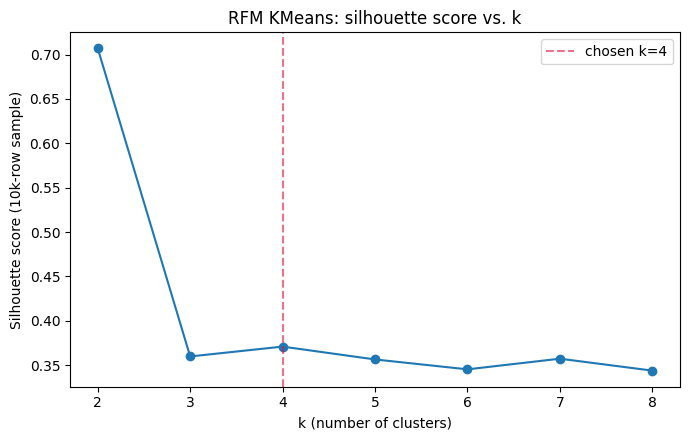

In [5]:
actionable_candidates = {k: v for k, v in sil_scores.items() if k >= 3}
best_k = max(actionable_candidates, key=actionable_candidates.get)
print(f"Statistically-best k: {statistically_best_k} (score={sil_scores[statistically_best_k]:.4f})")
print(f"Chosen k for segmentation (best among k>=3): {best_k} (score={sil_scores[best_k]:.4f})")

plt.figure(figsize=(7, 4.5))
ks = list(sil_scores.keys())
plt.plot(ks, [sil_scores[k] for k in ks], marker="o")
plt.axvline(best_k, color="crimson", linestyle="--", alpha=0.6, label=f"chosen k={best_k}")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score (10k-row sample)")
plt.title("RFM KMeans: silhouette score vs. k")
plt.legend()
plt.tight_layout()
plt.show()

## Fit final model and profile segments

In [6]:
final_km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
rfm["cluster"] = final_km.fit_predict(X_scaled)

profile = rfm.groupby("cluster").agg(
    n_customers=("customer_unique_id", "count"),
    avg_recency_days=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_monetary=("monetary", "sum"),
).reset_index()
profile["pct_customers"] = profile["n_customers"] / profile["n_customers"].sum() * 100
profile["pct_revenue"] = profile["total_monetary"] / profile["total_monetary"].sum() * 100
profile = profile.sort_values("avg_monetary", ascending=False).reset_index(drop=True)

# Name segments by rank, not fixed thresholds — frequency is ~1.0 for most
# clusters here, so a hard frequency cutoff is nearly meaningless.
profile["recency_rank"] = profile["avg_recency_days"].rank()
profile["monetary_rank"] = profile["avg_monetary"].rank(ascending=False)

def name_segment(row, profile_df):
    if row["avg_frequency"] >= 1.5:
        return "Repeat / Loyal Customers"
    if row["recency_rank"] == profile_df["recency_rank"].max():
        return "Lapsed / Win-Back Target"
    if row["monetary_rank"] == 1:
        return "High-Value One-Time Buyers"
    return "Low-Value / Price-Sensitive"

profile["segment_name"] = profile.apply(lambda r: name_segment(r, profile), axis=1)
rfm["segment_name"] = rfm["cluster"].map(dict(zip(profile["cluster"], profile["segment_name"])))
profile

,cluster,n_customers,avg_recency_days,avg_frequency,avg_monetary,total_monetary,pct_customers,pct_revenue,recency_rank,monetary_rank,segment_name
0,0,27855,173.521199,1.000000,318.228870,8864265.16,29.836757,57.486350,2.0,1.0,High-Value One-Time Buyers
1,3,2801,220.294538,2.113888,308.528190,864187.46,3.000278,5.604411,3.0,2.0,Repeat / Loyal Customers
2,2,27007,425.379902,1.000000,119.465440,3226403.15,28.928426,20.923803,4.0,3.0,Lapsed / Win-Back Target
3,1,35695,147.781342,1.000000,69.054993,2464917.98,38.234538,15.985435,1.0,4.0,Low-Value / Price-Sensitive


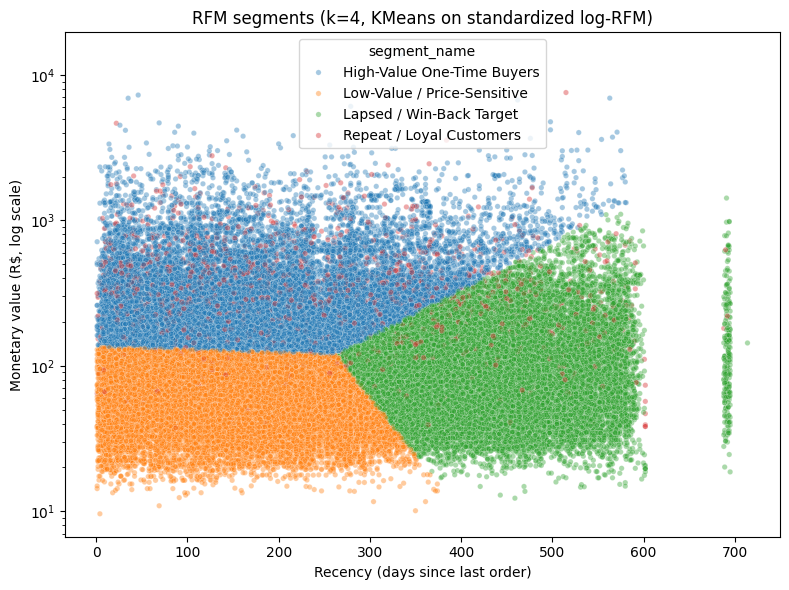

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=rfm, x="recency_days", y="monetary", hue="segment_name",
    alpha=0.4, s=15, palette="tab10",
)
plt.yscale("log")
plt.xlabel("Recency (days since last order)")
plt.ylabel("Monetary value (R$, log scale)")
plt.title(f"RFM segments (k={best_k}, KMeans on standardized log-RFM)")
plt.tight_layout()
plt.show()

In [8]:
rfm.to_csv(RESULTS / "rfm_segments.csv", index=False)
profile.to_csv(RESULTS / "rfm_cluster_profile.csv", index=False)

summary = {
    "snapshot_date": str(snapshot_date.date()),
    "n_customers": int(len(rfm)),
    "silhouette_scores_by_k": {str(k): round(v, 4) for k, v in sil_scores.items()},
    "statistically_best_k": int(statistically_best_k),
    "statistically_best_k_silhouette": round(sil_scores[statistically_best_k], 4),
    "statistically_best_k_note": (
        "k=2 wins on silhouette because ~97% of customers have frequency==1 "
        "(one-time buyers) — geometrically clean but not a usable business "
        "segmentation."
    ),
    "chosen_k_for_segmentation": int(best_k),
    "chosen_k_silhouette": round(sil_scores[best_k], 4),
    "cluster_profile": profile.to_dict(orient="records"),
}
with open(RESULTS / "rfm_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved: results/rfm_segments.csv, results/rfm_cluster_profile.csv, results/rfm_summary.json")

Saved: results/rfm_segments.csv, results/rfm_cluster_profile.csv, results/rfm_summary.json
